## General stuff
Guassian:\
$\phi(x) = e^{-\|x\|^2}$

Image function:\
$ f : \mathbb{R}^2 \to \mathbb{R}$

Approximation:\
$ \hat{f}(x) = \sum^n_{i=0}\alpha_i (g_i \triangleright \phi)(y) = \sum^n_{i=0}\alpha_i (\psi(v_i) \triangleright \phi)(y)$

Lie group (dim 6):\
$G = \text{Aff}^+(2)$

Group action on $R^2$:\
For $g \in G, y \in R^2$ then $g \triangleright y = (x, A) \triangleright y := Ay + x$

For $f : \mathbb{R}^2 \to \mathbb{R}$ then $(g \triangleright f)(y) := f(g^{-1} \triangleright y)$ 

Parameter space (dim 6):\
$V = \mathbb{R}^2 \times \text{SO}(2) \times \text{SNM}(2)$

Mapping:\
$\psi : V \to G$\
$\psi(L, X, Y) = (L, \exp(X)\exp(Y))$

For $X = \begin{pmatrix}
0 & b \\
-b & 0
\end{pmatrix}$ then $\exp(X) = \begin{pmatrix}
\cos(b) & \sin(b) \\
-\sin(b) & \cos(b)
\end{pmatrix}$

For
$
Y=\begin{pmatrix}a & b \\ b & c\end{pmatrix},
$
define
$
m=\tfrac{a+c}{2}, \quad 
B = Y - mI = \begin{pmatrix}\tfrac{a-c}{2} & b \\[4pt] b & -\tfrac{a-c}{2}\end{pmatrix}, \quad 
s=\sqrt{b^{2}+\left(\tfrac{a-c}{2}\right)^{2}}.
$

Then
$
\exp(Y) \;=\; e^{\,m}\!\left( \cosh(s)\,I + \frac{\sinh(s)}{s}\,B \right).
$

Loss:\
$\mathcal{L} = \|f-\hat{f}\|_{L^2}$

In [159]:
import torch
import numpy as np
import math
from pytorch_msssim import SSIM

In [160]:
# Mapping from parametric space to lie group

# Map exp of the theta of a 2x2 anti symmetric matrix to explicit
def exp_SO(theta: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.stack([torch.cos(theta), -torch.sin(theta)]),
                         torch.stack([torch.sin(theta), torch.cos(theta)])]).permute(2, 0, 1)

# Map exp of 2x2 symmetric matrix to explicit
def exp_SNM(a: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    m = torch.stack([
        torch.stack([torch.exp(a), torch.zeros_like(c)]),
        torch.stack([torch.zeros_like(a), torch.exp(c)])
    ]).permute(2, 0, 1)

    return m




In [161]:
class LinearSigmoid(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        return 1 / (1 + torch.exp(-x))

    @staticmethod
    def backward(ctx, grad_out):
        return grad_out

In [ ]:
def f_hat(
    color_zeroth: torch.Tensor,
    color_first: torch.Tensor,
    color_second: torch.Tensor,
    scale_shear: torch.Tensor,
    rotation: torch.Tensor,
    translation: torch.Tensor,
    width: int,
    height: int
) -> torch.Tensor:
    """
    Calculate f_hat with w for the grid width to height
    """

    Y = exp_SNM(scale_shear[:, 0], scale_shear[:, 1])

    A = exp_SO(rotation) @ Y

    sampling_grid = torch.nn.functional.affine_grid(
        torch.cat([torch.linalg.inv(A), (torch.linalg.inv(A) @ (translation*-1).unsqueeze(-1))], dim=-1), 
        torch.Size((A.size()[0], 1, height, width)))
    zeroth_gaussian_values = torch.exp(-1 * (sampling_grid[:,:,:,1]**2 + sampling_grid[:,:,:,0]**2))
    zeroth_image = torch.einsum('gjk,gd->gdjk', zeroth_gaussian_values, color_zeroth).sum(dim=0)

    first_gaussian_values =  -2 * (sampling_grid[:, :,:, 0]/0.7) * torch.exp(-1 * ((sampling_grid[:,:,:,0]/0.7)**2 + sampling_grid[:,:,:,1]**2))
    first_image = torch.einsum('gjk,gd->gdjk', first_gaussian_values, color_first).sum(dim=0)

    second_gaussian_values = (4 * (sampling_grid[:, :,:, 0]/0.5)**2 - 2) * torch.exp(-1 * ((sampling_grid[:,:,:,0]/0.5)**2 + sampling_grid[:,:,:,1]**2))
    second_image = torch.einsum('gjk,gd->gdjk', second_gaussian_values, color_second).sum(dim=0)

    # print(zeroth_gaussian_values.shape, color_zeroth.abs().shape)
    return LinearSigmoid.apply(zeroth_image + first_image + second_image)
    # return zeroth_image + first_image + second_image + 0.5


In [ ]:

torch.autograd.set_detect_anomaly(False)

device = torch.device("cuda:0")

def train(learning_rate: float, iterations: int, guassians: int, target: torch.Tensor, normalize_only_alpha: bool):

    ssim_module = SSIM(data_range=1, size_average=True, channel=3)
    lambda_ = 0.9

    color_zeroth = torch.randn(guassians, 3, device=device).abs().requires_grad_(True)
    color_first = (torch.randn(guassians, 3, device=device)*0.1).requires_grad_(True)
    color_second = (torch.randn(guassians, 3, device=device)*0.1).requires_grad_(True)

    scale_shear = torch.tensor(torch.randn(guassians, 2, device=device) - 4).requires_grad_(True)
    rotation = torch.tensor((torch.rand(guassians, device=device) - 0.5) * math.pi * 2, requires_grad=True)
    translation = torch.randn(guassians, 2, device=device, requires_grad=True)

    optimizer = torch.optim.AdamW(
        [
            color_zeroth,
            (color_first), 
            (color_second), 
            scale_shear,
            rotation,
            translation,
        ],
        lr=learning_rate,
        betas=(0.5, 0.9),
    )
    scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=iterations)

    mask = torch.ones(guassians, dtype=torch.bool, device=device)

    for iteration in range(iterations):

        preds = f_hat(
            color_zeroth[mask], 
            (color_first[mask]), 
            (color_second[mask]), 
            scale_shear[mask],
            rotation[mask],
            translation[mask],
            target.size()[1], target.size()[2])

        # loss = (target - preds).abs().mean()# + torch.where(w[1].abs() > w[2].abs(), (w[1].abs()/w[2].abs()), (w[2].abs()/w[1].abs())).mean() * 0.01
        ssim_loss = 1 - ssim_module(preds.unsqueeze(0), target.unsqueeze(0))
        l1_loss = (target - preds).abs().mean()
        
        loss = (1 - lambda_) * ssim_loss + lambda_ * l1_loss + (scale_shear[:, 0] - scale_shear[:, 1]).abs().mean() * 0.1 + torch.exp(-scale_shear.sum(1)-8).mean() * 0.1

        loss.backward()
        # print(rotation.grad)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        if iterations > 10 and (iteration + 1) % round(iterations/10) == 0:
            print(f"Iteration {iteration+1}/{iterations}")
            print(f"Loss: {loss.item():0.5f}")

        if round(iterations/10)*7 == iteration:
            mask = scale_shear.sum(1) > -7.5
            print(f"Culling {mask.sum()}")
            
    preds = f_hat(
            color_zeroth[mask], 
            color_first[mask], 
            color_second[mask], 
            scale_shear[mask],
            rotation[mask],
            translation[mask],
            target.size()[1], target.size()[2])
    ssim_loss = 1 - ssim_module(preds.unsqueeze(0), target.unsqueeze(0))
    l1_loss = (target - preds).abs().mean()
    loss = (1 - lambda_) * ssim_loss + lambda_ * l1_loss + (scale_shear[:, 0] - scale_shear[:, 1]).abs().mean() * 0.1

    return loss, color_zeroth[mask], color_first[mask], color_second[mask], scale_shear[mask], rotation[mask], translation[mask]

In [164]:
import torchvision

def img_to_tensor(img_path: str) -> torch.Tensor:
    return torchvision.io.read_image(img_path)

In [165]:
import matplotlib.pyplot as plt
# plot 2D image of gaussian function
def plot_image(color_zeroth: torch.Tensor,
    color_first: torch.Tensor,
    color_second: torch.Tensor,
    scale_shear: torch.Tensor,
    rotation: torch.Tensor,
    translation: torch.Tensor, resolution):
    color_zeroth = color_zeroth.detach().cpu()
    color_first = color_first.detach().cpu()
    color_second = color_second.detach().cpu()
    scale_shear = scale_shear.detach().cpu()
    rotation = rotation.detach().cpu()
    translation = translation.detach().cpu()
    plt.title("2D Gaussian")
    plt.imshow(f_hat(color_zeroth, color_first, color_second, scale_shear, rotation, translation, resolution, resolution).permute(1, 2, 0), origin='upper', vmin=0, vmax=1)
    plt.show()

In [166]:
def plot_accents(color_first: torch.Tensor,
    color_second: torch.Tensor,
    scale_shear: torch.Tensor,
    rotation: torch.Tensor,
    translation: torch.Tensor, resolution):
    color_first = color_first.detach().cpu()
    color_second = color_second.detach().cpu()
    scale_shear = scale_shear.detach().cpu()
    rotation = rotation.detach().cpu()
    translation = translation.detach().cpu()

    f_hat_result = f_hat(torch.zeros_like(color_first), color_first, color_second, scale_shear, rotation, translation, resolution, resolution).permute(1, 2, 0)
    print(torch.gather(f_hat_result, -1, f_hat_result.abs().max(-1, keepdim=True)[1]).shape)

    plt.title("2D Gaussian Accents")
    plt.imshow(
        torch.gather(f_hat_result, -1, f_hat_result.abs().max(-1, keepdim=True)[1]).squeeze(), origin='upper', cmap="plasma", vmin=-1, vmax=1)

In [ ]:
# Execute above for functions


/var/home/victor/Code/bep/.venv/lib64/python3.13/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31824154..0.98537743].


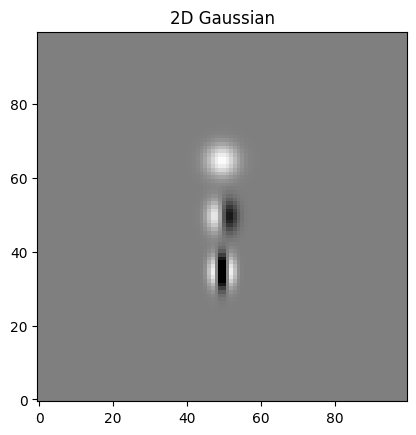

In [14]:
# w = torch.tensor([[-1,  -2, 1,  torch.pi/1.5, 0.5 - 2, 0.2 + 1], [-1,  -2, 1,  torch.pi/1.5, 0.5 - 2, 0.2 + 1]]).permute(1, 0)
w_prime = torch.tensor([[0, 0, 1,  -3, -3, -0.8,  0.45, 0.42], [1, 0, 0,  -2.5, -2.5, -0.8,  0.45, 0.42]]).permute(1, 0)

color_zeroth = torch.tensor([[0.5, 0.5, 0.5], [0, 0, 0], [0, 0, 0]])
color_first = torch.tensor([[0, 0, 0], [0.5, 0.5, 0.5], [0, 0, 0]])
color_second = torch.tensor([[0, 0, 0], [0, 0, 0], [0.5, 0.5, 0.5]])
scale_shear = torch.tensor([[ -2.5, -2.5], [ -2.5, -2.5], [ -2.5, -2.5]])
rotation = torch.tensor([0, 0, 0])
translation = torch.tensor([[0, 0.3], [0, 0], [0, -0.3]])

plt.title("2D Gaussian")
plt.imshow(f_hat(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 100, 100).permute(1, 2, 0), origin='lower', vmin=0, vmax=1)
plt.show()

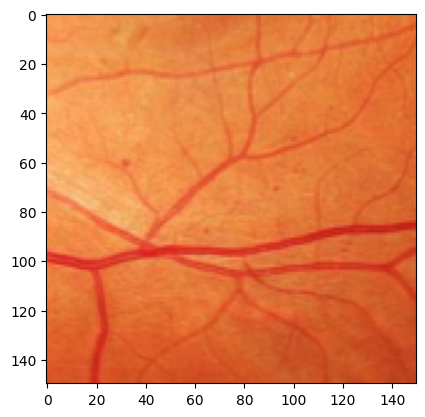

In [13]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()
img = torchvision.transforms.Resize(150)(img).permute(1, 2, 0) / 255

plt.imshow(img, origin='upper')

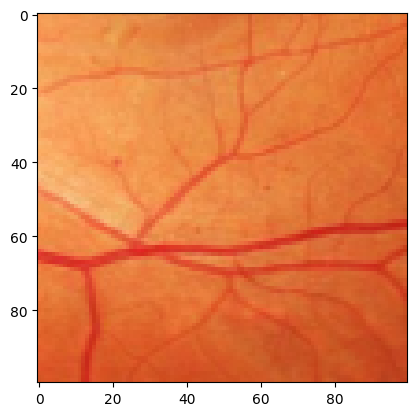

In [14]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()

learning_rate = 0.01
iterations = 1000
guassians = 2000

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(100)(img).to(device) / 255.0
plt.imshow(output_z.cpu().permute(1, 2, 0), origin='upper')

In [15]:
loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z, True)

/tmp/ipykernel_108185/2309214155.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale_shear = torch.tensor(torch.randn(guassians, 2, device=device) - 4).requires_grad_(True)
/tmp/ipykernel_108185/2309214155.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rotation = torch.tensor((torch.rand(guassians, device=device) - 0.5) * math.pi * 2, requires_grad=True)


Iteration 100/1000
Loss: 0.17148
Iteration 200/1000
Loss: 0.04735
Iteration 300/1000
Loss: 0.03089
Iteration 400/1000
Loss: 0.02349
Iteration 500/1000
Loss: 0.01970
Iteration 600/1000
Loss: 0.01803
Iteration 700/1000
Loss: 0.01641
Iteration 800/1000
Loss: 0.01526
Culling 841
Iteration 900/1000
Loss: 0.01870
Iteration 1000/1000
Loss: 0.01797


tensor(0.0180, device='cuda:0', grad_fn=<AddBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07283491..1.0027297].


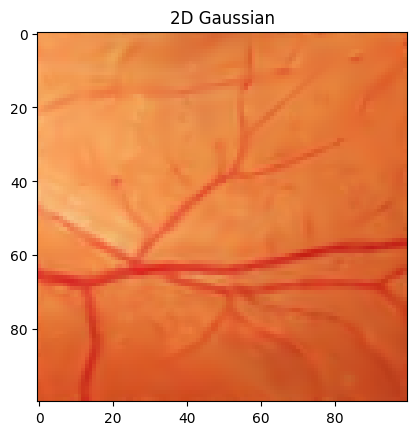

In [16]:
print(loss)
mask = color_zeroth.abs().mean(0) < 0.1
plot_image((color_zeroth), (color_first), (color_second), scale_shear, rotation, translation, 100)

tensor(0.0180, device='cuda:0', grad_fn=<AddBackward0>)


torch.Size([150, 150, 1])


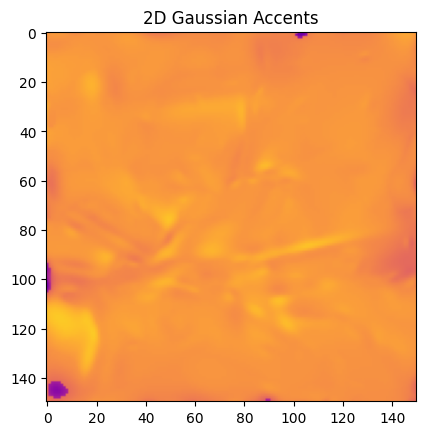

In [17]:
print(loss)
mask = scale_shear.sum(1) > -7
plot_accents((color_first[mask]), torch.zeros_like(color_second[mask]), scale_shear[mask], rotation[mask], translation[mask], 150)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07856125..1.0000002].


torch.Size([3, 100, 100])


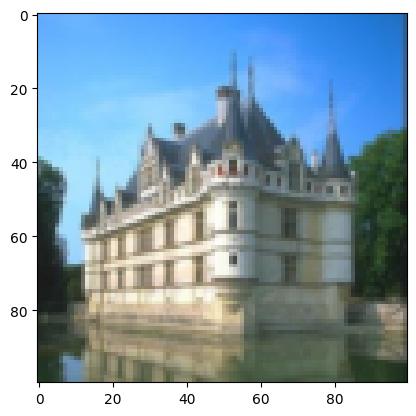

In [167]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd300-castle.jpg'), 0, 0, 321, 321).float()

learning_rate = 0.01
iterations = 750
guassians = 750

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(100)(img).to(device) / 255.0
plt.imshow(output_z.cpu().permute(1, 2, 0), origin='upper', vmin=0, vmax=1)

print(output_z.size())

In [168]:
loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z, True)

print(loss)

/tmp/ipykernel_13795/3080423111.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale_shear = torch.tensor(torch.randn(guassians, 2, device=device) - 4).requires_grad_(True)
/tmp/ipykernel_13795/3080423111.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rotation = torch.tensor((torch.rand(guassians, device=device) - 0.5) * math.pi * 2, requires_grad=True)


Iteration 75/750
Loss: 0.30381
Iteration 150/750
Loss: 0.16679
Iteration 225/750
Loss: 0.10074
Iteration 300/750
Loss: 0.07682
Iteration 375/750
Loss: 0.06682
Iteration 450/750
Loss: 0.06164
Iteration 525/750
Loss: 0.05847
Culling 748
Iteration 600/750
Loss: 0.05658
Iteration 675/750
Loss: 0.05513
Iteration 750/750
Loss: 0.05420
tensor(0.0419, device='cuda:0', grad_fn=<AddBackward0>)


tensor(0.0419, device='cuda:0', grad_fn=<AddBackward0>)
748
tensor(726, device='cuda:0')


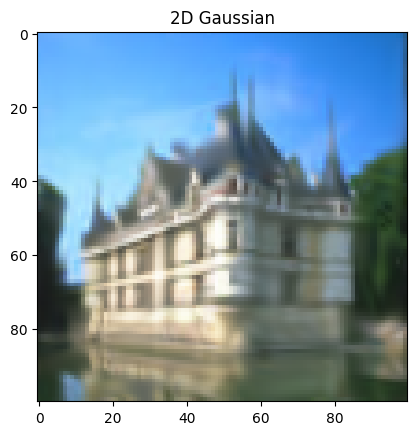

In [169]:
print(loss)
mask = scale_shear.sum(1) > -7
print(len(mask))
print(mask.sum())
plot_image((color_zeroth), (color_first), (color_second), scale_shear, rotation, translation, 100)

tensor(0.0419, device='cuda:0', grad_fn=<AddBackward0>)


/var/home/victor/Code/bep/.venv/lib64/python3.13/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


torch.Size([150, 150, 1])


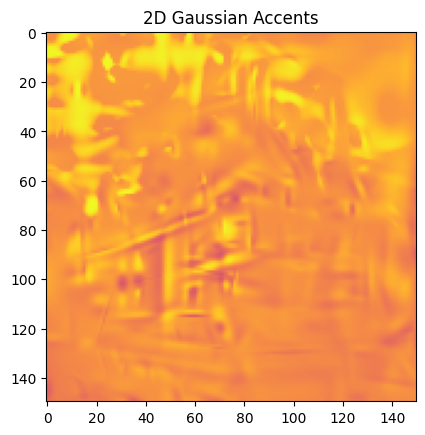

In [171]:
print(loss)
plot_accents((color_first[mask]), (color_second[mask]), scale_shear[mask], rotation[mask], translation[mask], 150)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12537353..1.0000002].


torch.Size([3, 321, 321])


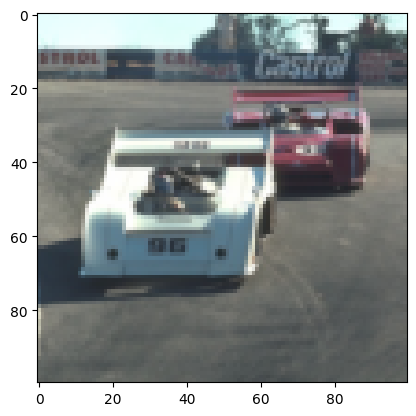

In [75]:

img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd68-0005.png'), 0, 440-321, 321, 321).float()

print(img.size())

learning_rate = 0.01
iterations = 750
guassians = 750

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(100)(img).to(device) / 255.0
plt.imshow(output_z.cpu().permute(1, 2, 0), origin='upper', vmin=0, vmax=1)



In [76]:
loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z, True)

print(loss)

/tmp/ipykernel_13795/227231530.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale_shear = torch.tensor(torch.randn(guassians, 2, device=device) - 4).requires_grad_(True)
/tmp/ipykernel_13795/227231530.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rotation = torch.tensor((torch.rand(guassians, device=device) - 0.5) * math.pi * 2, requires_grad=True)


Iteration 75/750
Loss: 0.30549
Iteration 150/750
Loss: 0.17125
Iteration 225/750
Loss: 0.10388
Iteration 300/750
Loss: 0.07466
Iteration 375/750
Loss: 0.06133
Iteration 450/750
Loss: 0.05246
Iteration 525/750
Loss: 0.04722
Culling 745
Iteration 600/750
Loss: 0.04395
Iteration 675/750
Loss: 0.04199
Iteration 750/750
Loss: 0.04061
tensor(0.0282, device='cuda:0', grad_fn=<AddBackward0>)


tensor(0.0282, device='cuda:0', grad_fn=<AddBackward0>)


torch.Size([128, 128, 1])


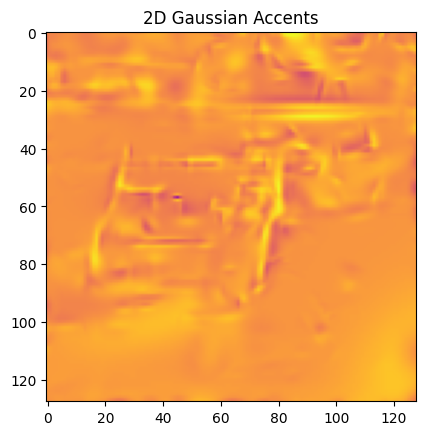

In [77]:
print(loss)
plot_accents((color_first), (color_second), scale_shear, rotation, translation, 128)

tensor(0.0282, device='cuda:0', grad_fn=<AddBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10813135..1.1012791].


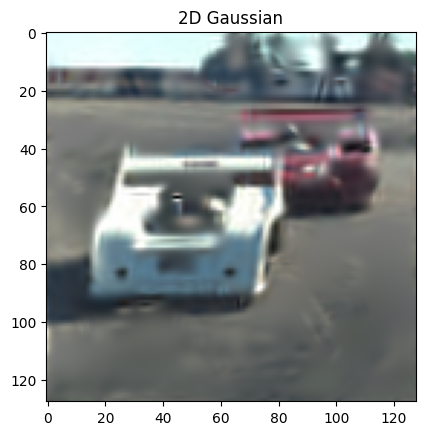

In [78]:
print(loss)
plot_image((color_zeroth), (color_first), (color_second), scale_shear, rotation, translation, 128)

tensor(0.0287, device='cuda:0', grad_fn=<AddBackward0>)
tensor(654, device='cuda:0')


/var/home/victor/Code/bep/.venv/lib64/python3.13/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07550798..1.8426206].


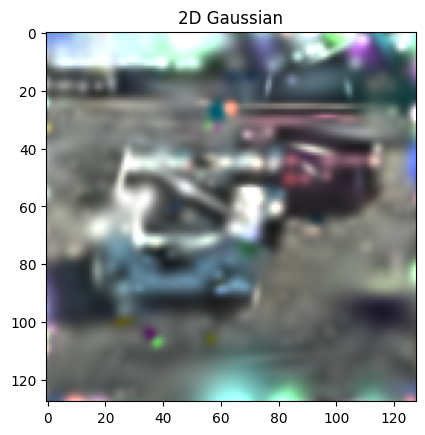

In [65]:
print(loss)
mask = scale_shear.sum(1) > -7
print(mask.sum())

plot_image((color_zeroth[mask]), torch.zeros_like(color_first[mask]), torch.zeros_like(color_second[mask]), scale_shear[mask], rotation[mask], translation[mask], 128)

torch.Size([3, 1024, 1024])


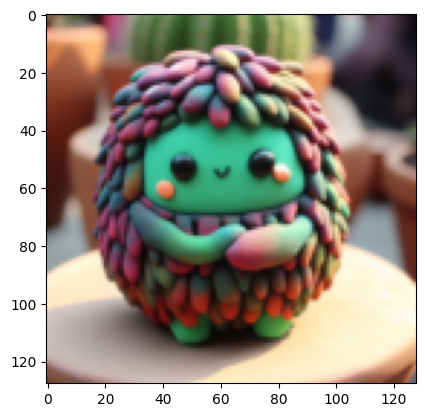

In [7]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/Image-01.png'), 0, 0, 1024, 1024).float()

print(torchvision.io.decode_image('./data/Image-01.png').size())

learning_rate = 0.01
iterations = 500
guassians = 2000

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(128)(img).to(device) / 255.0
plt.imshow(output_z.cpu().permute(1, 2, 0), origin='upper', vmin=0, vmax=1)


In [ ]:
loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z, True)

print(loss)

/tmp/ipykernel_67419/3174216075.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale_shear = torch.tensor(torch.randn(2, guassians, device=device) - 4).requires_grad_(True)
/tmp/ipykernel_67419/3174216075.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rotation = torch.tensor((torch.rand(guassians, device=device) - 0.5) * math.pi * 2, requires_grad=True)
/var/home/victor/Code/bep/.venv/lib64/python3.13/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.war

In [ ]:
print(loss)
plot_image(color_zeroth, (color_first), (color_second), scale_shear, rotation, translation, 128)

tensor(0.0170, device='cuda:0', grad_fn=<AddBackward0>)
